In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
connections_df = pd.read_feather("../data/task_connections_1507.feather")
locations_df = pd.read_feather("../data/task_cell_body_locations_1507.feather")

In [17]:
print(len(connections_df), "connections")
print(len(locations_df), "neurons with cell body locations")
print(len(connections_df["pre_pt_root_id"].unique()), "source neurons (outgoing connections traced)")

36320 connections
35046 neurons with cell body locations
66 source neurons (outgoing connections traced)


Hypothesis: the further apart two cell bodies are, the less likely they are to be connected.

Goal: Create plots on x-axis will show the distance, and y will be connectivity probablity

In [18]:
# distance for actual connections
connected = connections_df.merge(
    locations_df[["pt_root_id", "pt_position_x", "pt_position_y", "pt_position_z"]],
    left_on="pre_pt_root_id", right_on="pt_root_id",
).merge(
    locations_df[["pt_root_id", "pt_position_x", "pt_position_y", "pt_position_z"]],
    left_on="post_pt_root_id", right_on="pt_root_id", suffixes=("_pre", "_post"),
)

connected["distance_um"] = np.sqrt(
    (connected["pt_position_x_pre"] - connected["pt_position_x_post"]) ** 2
    + (connected["pt_position_y_pre"] - connected["pt_position_y_post"]) ** 2
    + (connected["pt_position_z_pre"] - connected["pt_position_z_post"]) ** 2
) / 1000  # nm to um

connected[["pre_pt_root_id", "post_pt_root_id", "syn_count", "distance_um"]].head()

,pre_pt_root_id,post_pt_root_id,syn_count,distance_um
0,864691134886663674,864691134885559290,1,287.929920
1,864691134886663674,864691134885735418,1,323.109912
2,864691134886663674,864691134886156026,1,148.443709
3,864691134886663674,864691134918210058,2,281.464943
4,864691134886663674,864691134918332682,2,333.937715


In [22]:
# distance from each source neuron to every other neuron
pre_ids = connections_df["pre_pt_root_id"].unique()

sources = pd.DataFrame({"pre_pt_root_id": pre_ids}).merge(
    locations_df, left_on="pre_pt_root_id", right_on="pt_root_id"
)
pre_xyz = sources[["pt_position_x", "pt_position_y", "pt_position_z"]].to_numpy()
all_xyz = locations_df[["pt_position_x", "pt_position_y", "pt_position_z"]].to_numpy()
all_ids = locations_df["pt_root_id"].to_numpy()

potential_dist = []
for i in range(len(pre_ids)):
    x1, y1, z1 = pre_xyz[i]
    for j in range(len(all_ids)):
        if pre_ids[i] == all_ids[j]:
            continue
        x2, y2, z2 = all_xyz[j]
        d = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)
        potential_dist.append(d)

potential_dist = np.array(potential_dist) / 1000  # nm to um
print(len(potential_dist))

2312970


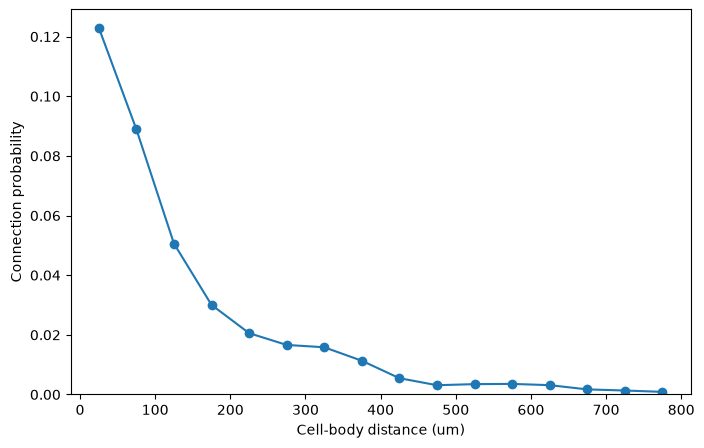

In [23]:
bin_edges = np.arange(0, 850, 50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

n_potential, _ = np.histogram(potential_dist, bins=bin_edges)
n_connected, _ = np.histogram(connected["distance_um"], bins=bin_edges)
connection_prob = n_connected / n_potential

plt.figure(figsize=(8, 5))
plt.plot(bin_centers, connection_prob, "o-")
plt.xlabel("Cell-body distance (um)")
plt.ylabel("Connection probability")
plt.ylim(bottom=0)
plt.show()

Connection probability is highest at short distances (~12% within 50 um) and drops sharply with distance, near zero beyond ~500 um. Supports the hypothesis that connectivity becomes less likely as cell-body distance increases.

### Extra

This plot shows the number of connections and the distance between them

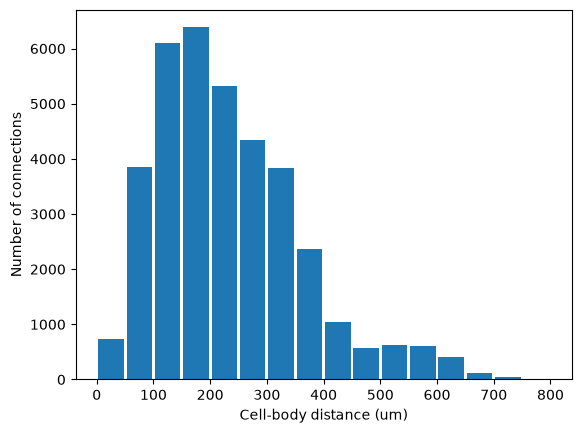

In [21]:
plt.bar(bin_centers, n_connected, width=45)
plt.xlabel("Cell-body distance (um)")
plt.ylabel("Number of connections")
plt.show()